# Bedah Arsitektur AttentiveSkel-3D V2: Transisi ke Evaluasi Per-Frame

Notebook ini disusun untuk membedah arsitektur **AttentiveSkel-3D V2** secara detail dan transparan.
Perubahan arsitektural ini merupakan tindak lanjut dari arahan evaluasi Dosen Penguji yang menolak konsep evaluasi global atau *rule-based* pada V1 (dengan argumen "salah satu salah semua tidak ada gunanya"). 

Oleh karena itu, lapisan Global Average Pooling (GAP) waktu dimodifikasi/dihapus agar urutan 64 frame tetap utuh. Selain itu, Classifier Head kini dirancang mengevaluasi secara independen per-frame, sehingga sistem V2 mampu mengevaluasi kesalahan gerakan secara mandiri di setiap potongan waktu (frame).

### 1. Import Library & Konfigurasi

In [16]:
# ============================================================
# Import library dan daftarkan src/ ke sys.path
# ============================================================
import sys
import os
from pathlib import Path
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

# Tambahkan direktori root proyek ke Python path
project_root = str(Path.cwd().parent.parent)
if project_root not in sys.path:
    sys.path.append(project_root)

# Import model V2 dan fungsi count_parameters
from src.models.v2.model_per_frame import AttentiveSkel3DPerFrame, count_parameters

# Tentukan device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Import berhasil.")
print(f"PyTorch versi : {torch.version}")
print(f"Device aktif  : {DEVICE}")

Import berhasil.
PyTorch versi : <module 'torch.version' from 'c:\\Users\\Administrator\\anaconda3\\envs\\attentiveskel\\lib\\site-packages\\torch\\version.py'>
Device aktif  : cuda


### 2. Inisialisasi Model

In [17]:
# ============================================================
# Buat instance model V2 lengkap dengan modul atensi
# ============================================================
model = AttentiveSkel3DPerFrame(
    use_spatial_prior=True,
    use_learned_spatial=True,
    use_temporal_attention=True
).to(DEVICE)

# Tampilkan ringkasan arsitektur model
print(model)
print()
print(f"Total parameter yang dapat dilatih: {count_parameters(model):,}")

AttentiveSkel3DPerFrame(
  (learned_spatial_attention): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=32, out_features=128, bias=True)
    (3): Sigmoid()
  )
  (temporal_attention): Sequential(
    (0): Conv3d(128, 1, kernel_size=(1, 1, 1), stride=(1, 1, 1))
  )
  (conv_block_1): Sequential(
    (0): Conv3d(3, 32, kernel_size=(3, 3, 1), stride=(1, 1, 1), padding=(1, 1, 0), bias=False)
    (1): BatchNorm3d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=(1, 2, 1), stride=(1, 2, 1), padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv3d(32, 64, kernel_size=(3, 3, 1), stride=(1, 1, 1), padding=(1, 1, 0), bias=False)
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool3d(kernel_size=(2, 2, 1), stride=(2, 2, 1), paddi

### 3. Rincian Parameter & Efisiensi Arsitektur (Ekstraksi Dinamis)

In [18]:
# ============================================================
# Hitung parameter secara dinamis per layer dan masukkan ke DataFrame
# ============================================================
layer_params = []

# Iterasi melalui named_children()
for name, child in model.named_children():
    params = sum(p.numel() for p in child.parameters() if p.requires_grad)
    layer_params.append({
        "Komponen Arsitektur": name,
        "Jumlah Parameter": params
    })

# Tangani parameter biomechanical_spatial_prior yang bukan berupa child module melainkan nn.Parameter
bsp_params = model.biomechanical_spatial_prior.numel() if model.biomechanical_spatial_prior.requires_grad else 0
layer_params.insert(0, {
    "Komponen Arsitektur": "biomechanical_spatial_prior",
    "Jumlah Parameter": bsp_params
})

df_params = pd.DataFrame(layer_params)
total_params = df_params["Jumlah Parameter"].sum()

print(f"TOTAL BEBAN PARAMETER MODEL: {total_params:,}\n")

# Tampilkan DataFrame dengan gradien warna biru
df_params.style.background_gradient(cmap='Blues', subset=['Jumlah Parameter'])

TOTAL BEBAN PARAMETER MODEL: 110,372



,Komponen Arsitektur,Jumlah Parameter
0,biomechanical_spatial_prior,33
1,learned_spatial_attention,8352
2,temporal_attention,129
3,conv_block_1,928
4,conv_block_2,18560
5,conv_block_3,73984
6,landmark_pool,0
7,classifier,8386


### 4. Forward Pass Sanity Check dengan Tensor Asli

In [19]:
# ============================================================
# Load sampel tensor NPY asli, ubah ke bentuk tensor PyTorch, 
# dan lakukan forward pass untuk memverifikasi output (1, 64, 2)
# ============================================================
path_tensor_asli = Path(project_root) / "data" / "processed" / "tensors" / "BenchPress_001.npy"

# Load tensor dan tambah dimensi batch (1, 64, 33, 3)
tensor_numpy = np.load(path_tensor_asli).astype(np.float32)
tensor_input = torch.tensor(tensor_numpy).unsqueeze(0).to(DEVICE)

print(f"Shape tensor input asli : {list(tensor_input.shape)}")
print(f" → (Batch=1, Frame=64, Landmark=33, Koordinat=3)\n")

model.eval() # Set mode evaluasi
with torch.no_grad():
    output = model(tensor_input)

print(f"Shape tensor output : {list(output.shape)}")
print(f" → (Batch={output.shape[0]}, Frame={output.shape[1]}, num_classes={output.shape[2]})\n")

# Validasi otomatis shape output
expected_shape = (1, 64, 2)
if tuple(output.shape) == expected_shape:
    print(f"[PASS] Shape output sesuai ekspektasi: {expected_shape}")
    print("Pembuktian mutlak secara kode berhasil! Model V2 mengevaluasi secara mandiri pada setiap potongan frame.")
else:
    print(f"[FAIL] Shape output tidak sesuai! Diharapkan {expected_shape}, didapat {tuple(output.shape)}")

Shape tensor input asli : [1, 64, 33, 3]
 → (Batch=1, Frame=64, Landmark=33, Koordinat=3)

Shape tensor output : [1, 64, 2]
 → (Batch=1, Frame=64, num_classes=2)

[PASS] Shape output sesuai ekspektasi: (1, 64, 2)
Pembuktian mutlak secara kode berhasil! Model V2 mengevaluasi secara mandiri pada setiap potongan frame.


### 5. Ringkasan Arsitektur dengan TorchInfo
Menampilkan rincian layer, jumlah parameter, dan memori yang digunakan.

In [20]:
# Menampilkan tabel ringkasan arsitektur tingkat lanjut
summary(model, input_size=(1, 64, 33, 3), 
        col_names=["input_size", "output_size", "num_params", "trainable"], 
        depth=3)

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
AttentiveSkel3DPerFrame                  [1, 64, 33, 3]            [1, 64, 2]                33                        True
├─Sequential: 1-1                        [1, 3, 64, 33, 1]         [1, 32, 64, 16, 1]        --                        True
│    └─Conv3d: 2-1                       [1, 3, 64, 33, 1]         [1, 32, 64, 33, 1]        864                       True
│    └─BatchNorm3d: 2-2                  [1, 32, 64, 33, 1]        [1, 32, 64, 33, 1]        64                        True
│    └─ReLU: 2-3                         [1, 32, 64, 33, 1]        [1, 32, 64, 33, 1]        --                        --
│    └─MaxPool3d: 2-4                    [1, 32, 64, 33, 1]        [1, 32, 64, 16, 1]        --                        --
├─Sequential: 1-2                        [1, 32, 64, 16, 1]        [1, 64, 32, 8, 1]         --                        True
│    └─

### 6. Visualisasi Distribusi Parameter (Donut Chart)
Membantu memvisualisasikan proporsi beban komputasi/parameter per blok di model.

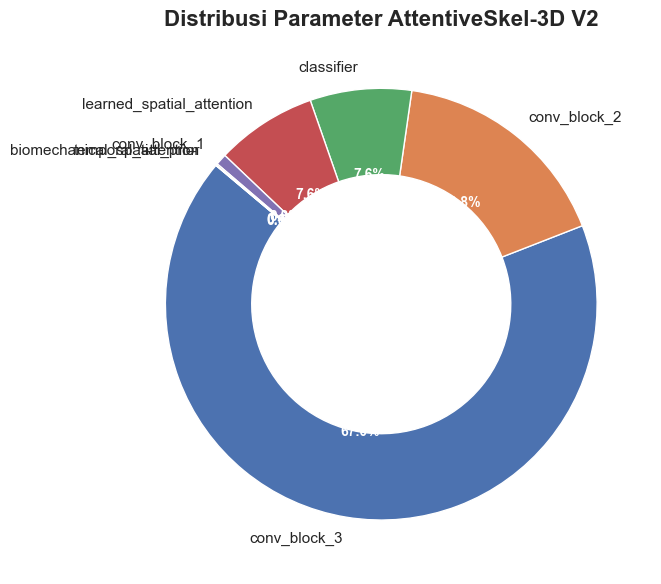

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter layer yang punya parameter > 0 agar chart terlihat rapi
df_plot = df_params[df_params["Jumlah Parameter"] > 0].copy()

# Sort descending
df_plot = df_plot.sort_values(by="Jumlah Parameter", ascending=False)

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(9, 6))

colors = sns.color_palette("deep", len(df_plot))
wedges, texts, autotexts = ax.pie(  # type: ignore
    df_plot["Jumlah Parameter"], 
    labels=df_plot["Komponen Arsitektur"], 
    autopct='%1.1f%%',
    startangle=140, 
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w') # Membuat bentuk Donut
)

plt.setp(autotexts, size=10, weight="bold", color="white")
plt.setp(texts, size=11)
ax.set_title("Distribusi Parameter AttentiveSkel-3D V2", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

### 7. Pelacakan Transformasi Tensor (Layer-by-Layer)
Eksperimen pembuktian matematis bahwa model mengevaluasi *Per-Frame* dengan cara melacak bentuk (shape) tensor step-by-step secara manual.

In [22]:
import torch.nn.functional as F
from IPython.display import display

trace = []
x = tensor_input # (1, 64, 33, 3) dari sel sebelumnya
trace.append({"Layer/Proses": "1. Input Awal (Raw Data)", "Shape Output": str(list(x.shape)), "Keterangan": "(Batch=1, Frame=64, Landmark=33, Koordinat=3)"})

x = x.permute(0, 3, 1, 2).unsqueeze(-1)
trace.append({"Layer/Proses": "2. Permute & Unsqueeze", "Shape Output": str(list(x.shape)), "Keterangan": "Siap untuk CNN 3D (B, C, T, L, W)"})

if model.use_spatial_prior:
    bsp_weights = torch.sigmoid(model.biomechanical_spatial_prior)
    x = x * bsp_weights
    trace.append({"Layer/Proses": "3. Biomechanical Spatial Prior", "Shape Output": str(list(x.shape)), "Keterangan": "Pembobotan fitur per-sendi (Landmark 33)"})

x = model.conv_block_1(x)
trace.append({"Layer/Proses": "4. Conv Block 1", "Shape Output": str(list(x.shape)), "Keterangan": "MaxPool hanya Landmark (33->16). Waktu tetap 64!"})

x = model.conv_block_2(x)
trace.append({"Layer/Proses": "5. Conv Block 2", "Shape Output": str(list(x.shape)), "Keterangan": "MaxPool Waktu (64->32) dan Landmark (16->8)"})

x = model.conv_block_3(x)
trace.append({"Layer/Proses": "6. Conv Block 3", "Shape Output": str(list(x.shape)), "Keterangan": "Ekspansi Channel ke 128. Tidak ada pooling."})

if model.use_learned_spatial:
    gap_feat = x.mean(dim=[2, 3, 4])
    ch_weights = model.learned_spatial_attention(gap_feat)
    x = x * ch_weights.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
    trace.append({"Layer/Proses": "7. Spatial (Channel) Attention", "Shape Output": str(list(x.shape)), "Keterangan": "Fokus pada channel krusial (SE-style)"})

if model.use_temporal_attention:
    scores = model.temporal_attention(x).mean(dim=[3, 4], keepdim=True)
    t_weights = torch.softmax(scores, dim=2)
    x = x * t_weights
    trace.append({"Layer/Proses": "8. Temporal Attention", "Shape Output": str(list(x.shape)), "Keterangan": "Fokus frame-level pada T=32"})

x = model.landmark_pool(x)
trace.append({"Layer/Proses": "9. Landmark Adaptive Pool", "Shape Output": str(list(x.shape)), "Keterangan": "Hanya agregasi spasial. (B, 128, T=32, 1, 1)"})

x = F.interpolate(x.squeeze(-1), size=(64, 1), mode="bilinear", align_corners=False).squeeze(-1)
trace.append({"Layer/Proses": "10. Bilinear Interpolation (Upsample)", "Shape Output": str(list(x.shape)), "Keterangan": "Kembalikan dimensi waktu T=32 menjadi T=64"})

x = x.permute(0, 2, 1)
trace.append({"Layer/Proses": "11. Permute & Prepare", "Shape Output": str(list(x.shape)), "Keterangan": "(Batch=1, Frame=64, Fitur=128)"})

x = model.classifier(x)
trace.append({"Layer/Proses": "12. Classifier Head (Final)", "Shape Output": str(list(x.shape)), "Keterangan": "Prediksi Mandiri (2 Kelas) Per-Frame"})

df_trace = pd.DataFrame(trace)
display(df_trace.style.set_properties(**{'background-color': '#F8F9FA', 'color': '#212529', 'border': '1px solid #DEE2E6', 'text-align': 'left'})
        .set_table_styles([{'selector': 'th', 'props': [('background-color', '#343A40'), ('color', 'white'), ('text-align', 'left')]}]))


,Layer/Proses,Shape Output,Keterangan
0,1. Input Awal (Raw Data),"[1, 64, 33, 3]","(Batch=1, Frame=64, Landmark=33, Koordinat=3)"
1,2. Permute & Unsqueeze,"[1, 3, 64, 33, 1]","Siap untuk CNN 3D (B, C, T, L, W)"
2,3. Biomechanical Spatial Prior,"[1, 3, 64, 33, 1]",Pembobotan fitur per-sendi (Landmark 33)
3,4. Conv Block 1,"[1, 32, 64, 16, 1]",MaxPool hanya Landmark (33->16). Waktu tetap 64!
4,5. Conv Block 2,"[1, 64, 32, 8, 1]",MaxPool Waktu (64->32) dan Landmark (16->8)
5,6. Conv Block 3,"[1, 128, 32, 8, 1]",Ekspansi Channel ke 128. Tidak ada pooling.
6,7. Spatial (Channel) Attention,"[1, 128, 32, 8, 1]",Fokus pada channel krusial (SE-style)
7,8. Temporal Attention,"[1, 128, 32, 8, 1]",Fokus frame-level pada T=32
8,9. Landmark Adaptive Pool,"[1, 128, 32, 1, 1]","Hanya agregasi spasial. (B, 128, T=32, 1, 1)"
9,10. Bilinear Interpolation (Upsample),"[1, 128, 64]",Kembalikan dimensi waktu T=32 menjadi T=64
